In [1]:
from strategy import *
P = load_params('params_strategy.par')

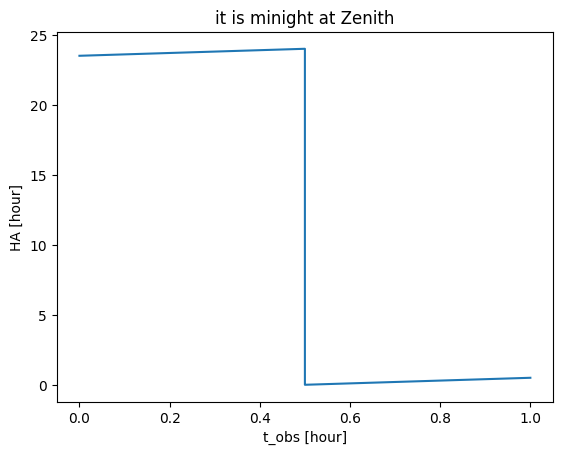

In [2]:
#The coordinates of the field
name=P['name_field']
c=SkyCoord.from_name(name)
ra = c.ra.value
dec = c.dec.value
#The contour of the field
contours = P['contours']
x_cen, y_cen = np.mean(contours[:, 1]), np.mean(contours[:, 0])

#load the observer position
lat = P['latitude']

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap.
T_duration = P['T_duration'] 
T = np.arange(0,T_duration,dt) * 3600
HA = np.arange(-T_duration/2,T_duration/2,dt) #hour
HAr = HA*np.pi/12
index, = np.where(HAr<0)
HAr[index] += 2*np.pi
HA = HAr*12/np.pi
plt.plot(T/3600, HA); plt.xlabel('t_obs [hour]'); plt.ylabel('HA [hour]')
plt.title('it is minight at Zenith')
#----------------------------------------
#Generate the scan path for the center of the arrays. 
az, alt, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)

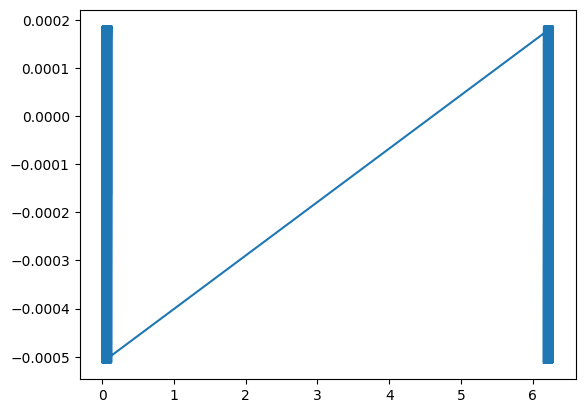

In [3]:

# Constants
decr = np.radians(scan_path[:,1])  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]

# Hour angle [rad]
HAr = HA * np.pi / 12  # Convert from hour to radians
plt.plot(HAr, decr)


Text(0, 0.5, 'Angle difference (deg)')

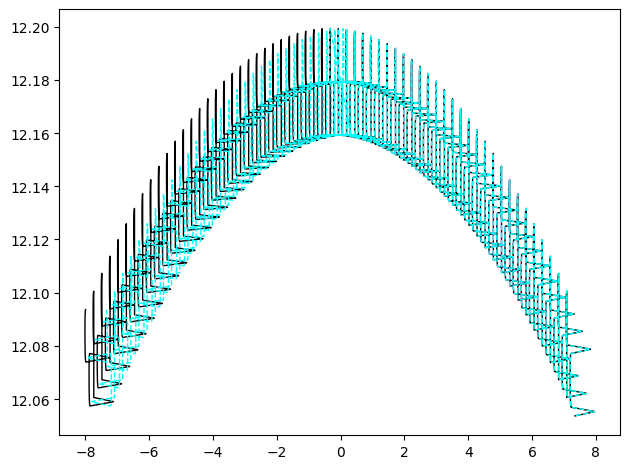

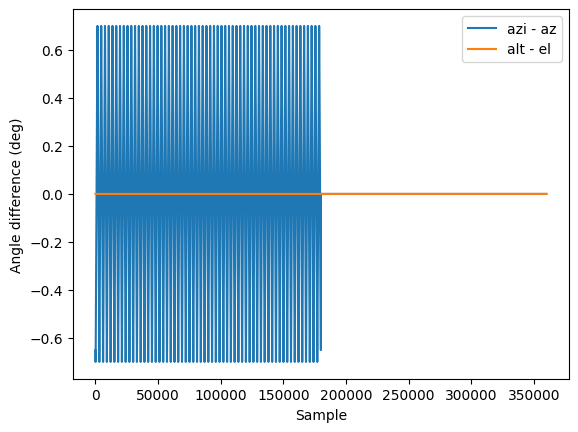

In [4]:
index, = np.where(np.sin(HAr)<0)

#Strategy formula
#-----------
za = np.arccos(np.sin(latr) * np.sin(decr) + np.cos(latr) * np.cos(decr) * np.cos(HAr))
alt = np.pi/2 - za
#alt += np.radians(scan_path[:,1])
sinAz = np.sin(HAr) * np.cos(decr) / np.sin(za)
cosAz = (np.sin(decr) - np.sin(latr) * np.cos(za))/(np.cos(latr) * np.sin(za))
azi = np.arctan2(sinAz,cosAz)
azi += np.radians(scan_path[:,0])  
azi[index] += 2*np.pi 
#-----------

#NAMAP formula
#-----------
el = np.arcsin(np.sin(decr)*np.sin(latr)+np.cos(latr)*np.cos(decr)*np.cos(HAr))
#el += np.radians(scan_path[:,1])
sin_az = -np.sin(HAr)*np.cos(latr) / np.cos(el)
cos_az = (np.sin(decr)-np.sin(latr)*np.sin(el))/(np.cos(latr)*np.cos(el))
az = np.arctan2(sin_az, cos_az)
az = np.arccos(cos_az)
az += np.radians(scan_path[:,0])  
az[index] = 2*np.pi - az[index]  
#-----------


for A,E,C,ls in zip((azi,az), (alt, el), ('k','cyan'), ('solid', '--')):
    AB = A.copy()
    AB[index]=AB[index]-2*np.pi
    plt.plot(np.degrees(AB),np.degrees(E), c=C, lw=1, ls=ls)
#plt.xlim(-10,10)
plt.tight_layout()
plt.figure()
plt.plot(np.degrees(azi - az), label="azi - az")
plt.plot(np.degrees(alt - el), label="alt - el")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Angle difference (deg)")


In [ ]:
times = np.arange(0,len(T),5000)
for t in times: 
    fig, axs = plt.subplots(1,2,figsize=(5,2.5), dpi=140,)
    INDEX, = np.where(np.sin(HAr)<0)
    axs[0].plot(np.degrees(azi[:t]),np.degrees(alt[:t]), 'k', lw=1)
    axs[0].plot(np.degrees(az[:t]),np.degrees(el[:t]), c='cyan', lw=1)
    axs[0].set_xlabel('az');axs[0].set_ylabel('alt')
    axs[1].set_xlabel('az');axs[1].set_ylabel('el')
    axs[0].set_xlim(0,360)
    for A,E,C,ls in zip((azi,az), (alt, el), ('k','cyan'), ('solid', '--')):
        AB = A.copy()
        INDEX, = np.where(np.sin(HAr)<0)
        AB[INDEX]=AB[INDEX]-2*np.pi
        axs[1].plot(np.degrees(AB[:t]),np.degrees(E[:t]), c=C, lw=1, ls=ls)
    axs[1].set_xlim(-10,10)
    plt.tight_layout()
    fig.savefig(f'plot/gframe{t:0f}.png')
    plt.close()

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(5,2.5), dpi=140,)
axs[0].plot(np.degrees(azi),np.degrees(alt), 'k', lw=1)
axs[0].plot(np.degrees(az),np.degrees(el), c='cyan', lw=1)
axs[0].set_xlabel('az');axs[0].set_ylabel('alt')
axs[1].set_xlabel('az');axs[1].set_ylabel('el')
axs[0].set_xlim(0,360)
axs[0].plot(np.degrees(azi[index]),np.degrees(alt[index]), ':g', lw=1)
axs[0].plot(np.degrees(az[index]),np.degrees(el[index]), ':g', lw=1)

for A,E,C,ls in zip((azi,az), (alt, el), ('k','cyan'), ('solid', '--')):
    AB = A.copy()
    AB[index]=AB[index]-2*np.pi
    axs[1].plot(np.degrees(AB),np.degrees(E), c=C, lw=1, ls=ls)
axs[1].set_xlim(-10,10)
plt.tight_layout()


In [ ]:
fig, axs = plt.subplots(2,3,figsize=(10,3), dpi=160,)
for Az,El,C,ls in zip((azi,az), (alt, el), ('k','cyan'), ('solid', )):
    dec_point = np.arcsin(np.sin(El)*np.sin(latr) + np.cos(El)*np.cos(latr)*np.cos(Az))
    
    axs[0,1].plot(HA, np.degrees(dec_point),ls=ls, c=C )
    dec = dec_point
    
    index, = np.where(np.sin(HA)<0)
    HAC = HA.copy()
    HAC[index]=HAC[index]-24
    axs[1,1].plot(HAC*15, np.degrees(dec),ls=ls, c=C)
    

    cosHA = ( np.sin(El)- np.sin(dec)*np.sin(latr) )/ (np.cos(dec)*np.cos(latr))
    ha_point = np.arccos(cosHA)
    axs[0,0].plot(np.degrees(ha_point), np.degrees(dec),ls=ls, c=C )   
    w = np.where((np.degrees(A) > 0) & (np.degrees(A) <= 180), 1, -1) 
    axs[1,0].plot(np.degrees(ha_point)*w, np.degrees(dec),ls=ls, c=C )   


    ha_final   = (ha_point+HA*np.pi/12)
    axs[0,2].plot(np.degrees(ha_final),np.degrees(dec), ls=ls, c=C )

    HAC = ha_final.copy()
    HAC[index]=HAC[index]-2*np.pi
    axs[1,2].plot(np.degrees(HAC), np.degrees(dec),ls=ls, c=C)
    #axs[1,2].plot(np.degrees(ha_final),np.degrees(dec), c=C, lw=1, ls=ls)

    W = np.where(np.degrees(HAC)>1)
    axs[1,2].plot(np.degrees(HAC)[W], np.degrees(dec)[W],     ls=":", c='magenta' )
    axs[0,2].plot(np.degrees(ha_final[W]),np.degrees(dec[W]), ls=":", c='magenta' )
    axs[1,1].plot(HAC[W]*15, np.degrees(dec[W]),              ls=":", c='magenta' )
    axs[0,1].plot(HA[W], np.degrees(dec_point)[W],            ls=":", c='magenta' )
    axs[1,0].plot((np.degrees(ha_point)*w)[W], np.degrees(dec[W]), ls=":", c='magenta' )
    axs[0,0].plot(np.degrees(ha_point)[W], np.degrees(dec)[W],ls=":", c='magenta' )   

    '''
    path = np.vstack((np.degrees(ha_final), np.degrees(dec_point))).T
    path[:,0] += 360.
    axs[0,2].plot(path[:,0], path[:,1],ls=ls, c=C )   
    index, = np.where(np.sin(ha_final)<0)
    path[index,0]=path[index,0]-360
    axs[1,2].plot(AB,path[:,1], c=C, lw=1, ls=ls)
    '''
plt.tight_layout()
print(W)

fig, axs = plt.subplots(1,2,figsize=(5,2.5), dpi=140,)
index, = np.where(np.sin(HAr)<0)
axs[0].plot(np.degrees(azi),np.degrees(alt), 'k', lw=1)
axs[0].plot(np.degrees(azi)[W],np.degrees(alt)[W],lw=1,ls=":", c='magenta' )   

#axs[0].plot(np.degrees(az),np.degrees(el), c='cyan', lw=1)
axs[0].set_xlabel('az');axs[0].set_ylabel('alt')
axs[1].set_xlabel('az');axs[1].set_ylabel('el')
axs[0].set_xlim(0,360)

for A,E,C,ls in zip((azi,az), (alt, el), ('k','cyan'), ('solid',)):
    AB = A.copy()
    index, = np.where(np.sin(HAr)<0)
    AB[index]=AB[index]-2*np.pi
    axs[1].plot(np.degrees(AB),np.degrees(E), c=C, lw=1, ls=ls)
    axs[1].plot(np.degrees(AB)[W],np.degrees(E)[W], ls=":", c='magenta' )   
axs[1].set_xlim(-10,10)
plt.tight_layout()

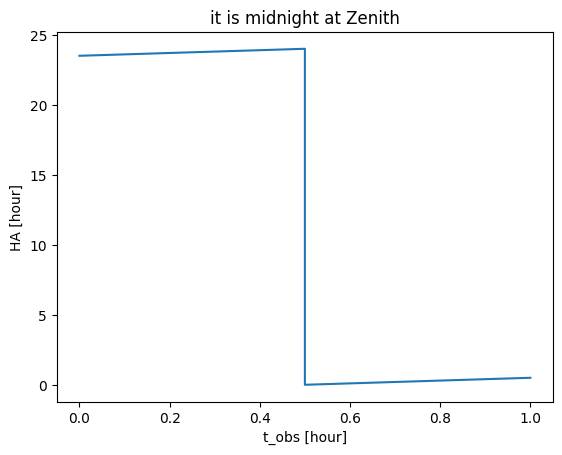

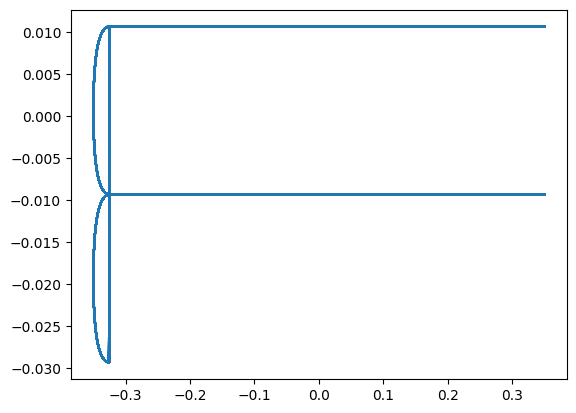

In [5]:
#The coordinates of the field
name=P['name_field']
c=SkyCoord.from_name(name)
ra = c.ra.value
dec = c.dec.value
#The contour of the field
contours = P['contours']
x_cen, y_cen = np.mean(contours[:, 1]), np.mean(contours[:, 0])

# Observer info
lat = -77.83
lon = 0  # arbitrary for South Pole
elev = 0  # assume sea level or adjust as needed

location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg, height=elev*u.m)

#load the observer position
lat = P['latitude']

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap.
T_duration = P['T_duration'] 
T = np.arange(0,T_duration,dt) * 3600
time_obs = Time('2025-01-01 00:00:00') + T * u.s

HA = np.arange(-T_duration/2,T_duration/2,dt) #hour
HAr = HA*np.pi/12
index, = np.where(HAr<0)
HAr[index] += 2*np.pi
HA = HAr*12/np.pi
plt.plot(T/3600, HA); plt.xlabel('t_obs [hour]'); plt.ylabel('HA [hour]')
plt.title('it is midnight at Zenith')
#----------------------------------------
#Generate the scan path for the center of the arrays. 
az, alt, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)
plt.figure(); 
plt.plot(scan_path[:,0],scan_path[:,1] )


In [6]:
# Constants
decr = np.radians(dec)  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]
# Hour angle [rad]
HAr = HA * np.pi / 12  # Convert from hour to radians

# Precompute trigonometric terms
sin_dec = np.sin(decr)
cos_dec = np.cos(decr)
sin_lat = np.sin(latr)
cos_lat = np.cos(latr)
cos_HA = np.cos(HAr)
sin_HA = np.sin(HAr)

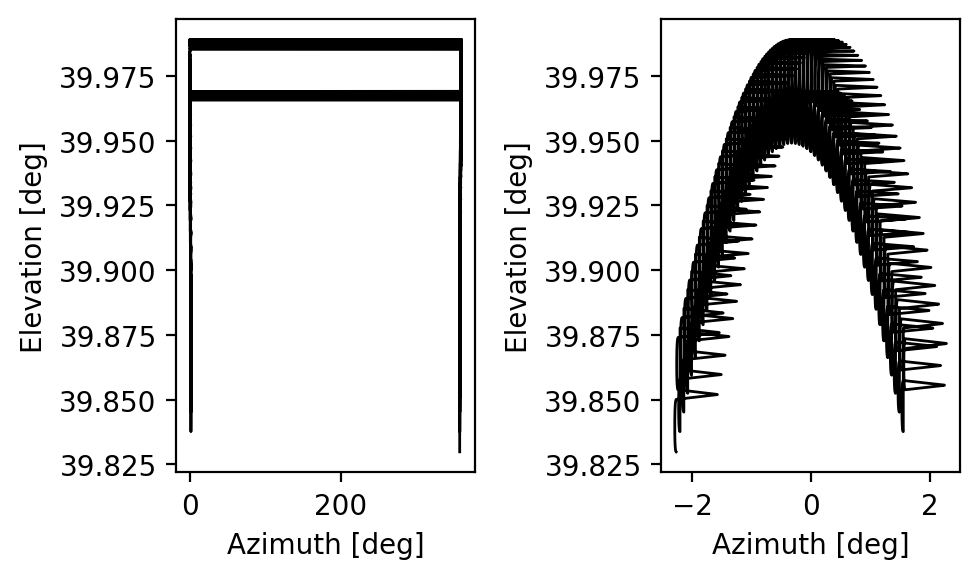

In [7]:
#-------------------
# Elevation
el = np.arcsin(
    sin_dec * sin_lat +
    cos_dec * cos_lat * cos_HA
)

# Azimuth (from North, increasing toward East)
az = np.arctan2(
    sin_HA * cos_dec,
    sin_dec - sin_lat * np.sin(el) / (cos_lat * np.cos(el))
)
#-------------------

# Normalize azimuth to [0, 2pi]
az = (az + 2 * np.pi) % (2 * np.pi)

# Apply scan offsets
az += np.radians(scan_path[:,0])
el += np.radians(scan_path[:,1])

# Wrap azimuth again if needed
az = (az + 2 * np.pi) % (2 * np.pi)

fig, axs = plt.subplots(1,2,figsize=(5,3),dpi=200)
axs[0].plot(np.degrees(az), np.degrees(el), c='k', lw=1, ls='-')
axs[0].set_xlabel("Azimuth [deg]")
axs[0].set_ylabel("Elevation [deg]")
# "Unwrap" from [0, 2π) to (-π, π]
az_unwrapped = (az + np.pi) % (2 * np.pi) - np.pi
axs[1].plot(np.degrees(az_unwrapped), np.degrees(el), c='k', lw=1, ls='-')
axs[1].set_xlabel("Azimuth [deg]")
axs[1].set_ylabel("Elevation [deg]")

plt.tight_layout()
plt.show()

times = np.arange(0,len(T),5000)
for t in times: 
    fig, axs = plt.subplots(1,2,figsize=(5,2.5), dpi=140,)
    axs[0].plot(np.degrees(az[:t]), np.degrees(el[:t]), c='k', lw=1, ls='-')
    axs[1].plot(np.degrees(az_unwrapped[:t]), np.degrees(el[:t]), c='k', lw=1, ls='-')
    axs[1].set_xlabel("Azimuth [deg]")
    axs[1].set_ylabel("Elevation [deg]")
    axs[0].set_xlabel("Azimuth [deg]")
    axs[0].set_ylabel("Elevation [deg]")
    axs[0].set_xlim(0,360)
    axs[1].set_xlim(-2.5,2.5)
    plt.tight_layout()
    fig.savefig(f'plot/gframe{t:0f}.png')
    plt.close()



In [ ]:
sin_el = np.sin(el)
cos_el = np.cos(el)
cos_az = np.cos(az)
sin_az = np.sin(az)  # <-- Now using correct southern hemisphere convention

# Compute declination
sin_dec_point = sin_el * sin_lat + cos_el * cos_lat * cos_az
dec_point = np.arcsin(sin_dec_point)
cos_dec_point = np.cos(dec_point)

# Correct computation of hour angle using atan2
sin_HA = -sin_az * cos_el / cos_dec_point
cos_HA = (sin_el - sin_lat * sin_dec_point) / (cos_lat * cos_dec_point)
ha_point = np.arctan2(sin_HA, cos_HA)

ha_point *= np.where(sin_az > 0, -1, 1)  # Sign from azimuth
#----
RA = np.radians(ra) + (HAr- ha_point)
RA = (RA + 2 * np.pi) % (2 * np.pi)
#----

path = np.vstack((np.degrees(RA), np.degrees(dec_point))).T
fig, axs = plt.subplots(1,2,figsize=(5,3),dpi=200)
axs[0].plot(path[:,0], path[:,1])
#w = np.where(path[:,0]<0)
#axs[0].plot(path[:,0][w]+360, path[:,1][w], ':g')
#RA = path[:,0][w]+360
#RA_unwrapped = (RA + np.pi) % (2 * np.pi) - np.pi
#axs[1].plot(RA_unwrapped, path[:,1][w], 'g')





In [ ]:
ha_point.min(), ha_point.max()